In [3]:
import pandas as pd
import os

# 1. Path Setup (stepping out of notebooks folder)
# We load the raw collection to clean it
input_path = '../data/processed/sentiment_results.csv' 
output_path = '../data/processed/bank_reviews_clean.csv'

if not os.path.exists(input_path):
    print(f"❌ Error: {input_path} not found. Please run your scraper cell first!")
else:
    # Load the data
    df = pd.read_csv(input_path)
    initial_count = len(df)
    
    # --- STEP A: REMOVE DUPLICATES ---
    # We use 'review' and 'date' as a unique identifier if 'review_id' is missing
    df = df.drop_duplicates(subset=['review', 'date'])
    
    # --- STEP B: HANDLE MISSING VALUES ---
    # Drop rows missing review text or rating
    df = df.dropna(subset=['review', 'rating'])
    
    # --- STEP C: NORMALIZE DATES ---
    # Convert to standard YYYY-MM-DD format
    df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
    
    # --- STEP D: FORMATTING & SAVING ---
    # Final column selection as requested
    df_final = df[['review', 'rating', 'date', 'bank', 'source']]
    
    # Documenting the counts
    final_count = len(df_final)
    dropped_count = initial_count - final_count
    
    # Save the cleaned dataset
    df_final.to_csv(output_path, index=False)
    
    print(f"✅ Data Preprocessing Successful!")
    print(f"--- Summary ---")
    print(f"Initial Records: {initial_count}")
    print(f"Cleaned Records: {final_count}")
    print(f"Dropped (Duplicates/Missing): {dropped_count}")
    print(f"Saved to: {output_path}")

    # Display the first few rows to verify the column headers
    display(df_final.head())

✅ Data Preprocessing Successful!
--- Summary ---
Initial Records: 11486
Cleaned Records: 11199
Dropped (Duplicates/Missing): 287
Saved to: ../data/processed/bank_reviews_clean.csv


,review,rating,date,bank,source
0,it's very good app,5,2026-05-12,BOA,Google Play
1,this app is good but the speed of app is very ...,2,2026-05-11,BOA,Google Play
2,good,5,2026-05-09,BOA,Google Play
3,boa the best,5,2026-05-08,BOA,Google Play
4,bank of absiniya is best bank in ethiopian,5,2026-05-07,BOA,Google Play


✅ Found 3 files. Loading data...


C:\Users\HP\AppData\Local\Temp\ipykernel_24648\4246798071.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='bank', y='rating', data=df, palette='magma', ci=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_24648\4246798071.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='bank', y='rating', data=df, palette='magma', ci=None)


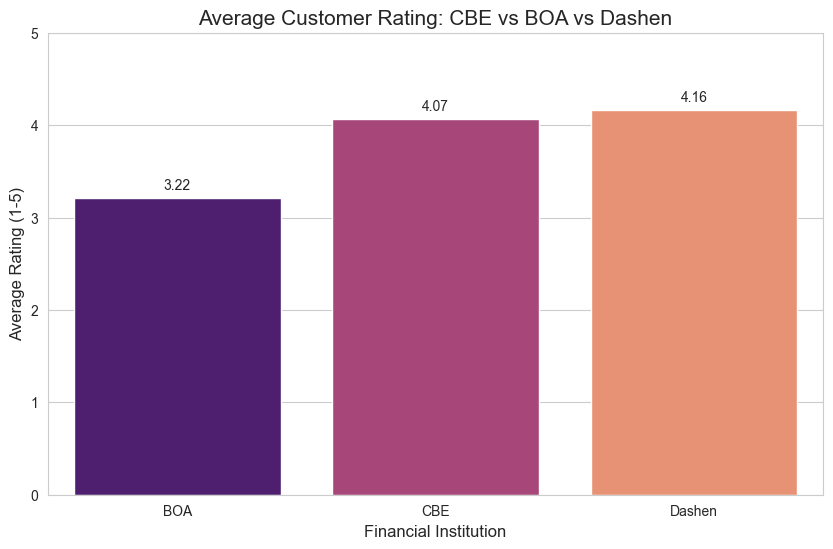

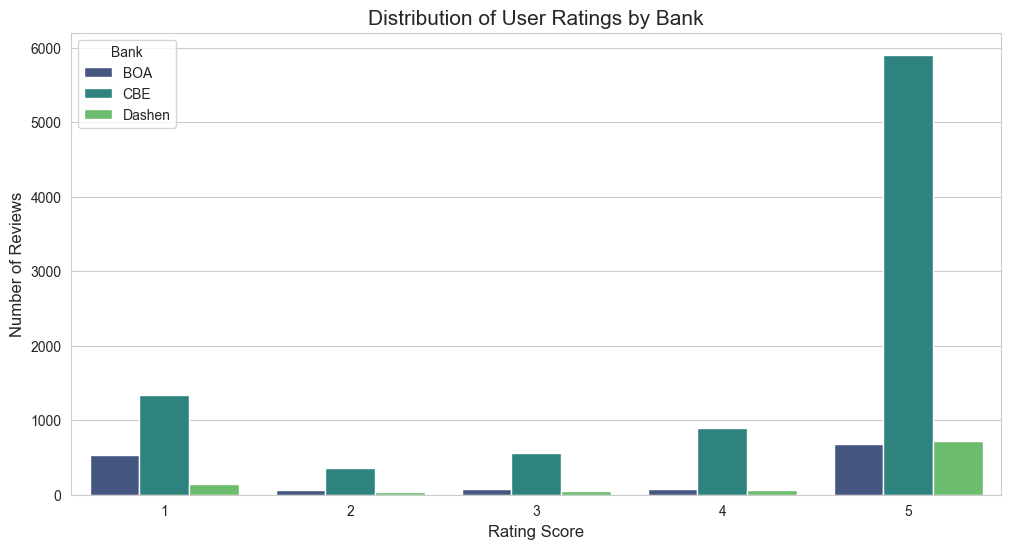

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

# 1. SEARCH FOR DATA FILES
# Checks for data files relative to the notebook's location
search_path = "../data/raw/*_reviews.csv"
all_files = glob.glob(search_path)

if not all_files:
    # Fallback check if notebook is run from the root directory
    all_files = glob.glob("data/raw/*_reviews.csv")

if not all_files:
    print("❌ Critical Error: No data files found! Ensure the scraper script has run successfully.")
else:
    # 2. LOAD AND CONSOLIDATE DATA
    print(f"✅ Found {len(all_files)} files. Loading data...")
    df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    df['date'] = pd.to_datetime(df['date'])

    # 3. VISUALIZATION: AVERAGE RATING BY BANK
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Calculate means for the plot
    ax = sns.barplot(x='bank', y='rating', data=df, palette='magma', ci=None)
    
    plt.title('Average Customer Rating: CBE vs BOA vs Dashen', fontsize=15)
    plt.ylabel('Average Rating (1-5)', fontsize=12)
    plt.xlabel('Financial Institution', fontsize=12)
    plt.ylim(0, 5) # Ratings are 1-5
    
    # Add data labels on top of bars
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')
    plt.show()

    # 4. VISUALIZATION: RATING DISTRIBUTION (1-5 STARS)
    plt.figure(figsize=(12, 6))
    sns.countplot(x='rating', hue='bank', data=df, palette='viridis')
    plt.title('Distribution of User Ratings by Bank', fontsize=15)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.xlabel('Rating Score', fontsize=12)
    plt.legend(title='Bank')
    plt.show()

In [1]:
import pandas as pd
import glob
import os

# 1. Search for files
search_path = "../data/raw/*_reviews.csv"
all_files = glob.glob(search_path)
if not all_files:
    all_files = glob.glob("data/raw/*_reviews.csv")

if not all_files:
    print("❌ No data found.")
else:
    # 2. ROBUST LOADING LOOP
    df_list = []
    for f in all_files:
        try:
            # Using 'python' engine is slower but more memory-stable for messy text
            # on_bad_lines='skip' ensures one broken row doesn't crash the whole notebook
            temp_df = pd.read_csv(f, engine='python', on_bad_lines='skip')
            df_list.append(temp_df)
            print(f"✅ Loaded {f}: {len(temp_df)} rows")
        except Exception as e:
            print(f"⚠️ Skipping {f} due to error: {e}")

    # 3. CONSOLIDATE
    if df_list:
        df = pd.concat(df_list, ignore_index=True)
        # Final Cleaning: Ensure 'rating' is numeric and drop any rows that failed to parse
        df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
        df = df.dropna(subset=['rating'])
        
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        print(f"\n🚀 Total Combined Dataset: {len(df)} rows")
    else:
        print("❌ Failed to load any valid data.")

✅ Loaded ../data/raw\BOA_reviews.csv: 1422 rows
✅ Loaded ../data/raw\CBE_reviews.csv: 9065 rows
✅ Loaded ../data/raw\Dashen_reviews.csv: 1012 rows

🚀 Total Combined Dataset: 11499 rows
